# Support Vector Machine

In [32]:
import pandas as pd

In [33]:
df=pd.read_csv('Employee_Attrition.csv')
df.head()

,Employee_ID,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,1,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,2,56,31395,18,HR,Poor,Yes,1,7,School,1
2,3,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,4,39,20851,5,HR,Good,No,2,7,Graduate,0
4,5,28,32156,12,Developer,Good,No,3,26,School,0


In [34]:
df.isna().sum()

Employee_ID           0
Age                   0
Monthly_Income        0
Years_at_Company      0
Job_Role              0
Work_Life_Balance     0
Overtime              0
Job_Satisfaction      0
Distance_From_Home    0
Education             0
Attrition             0
dtype: int64

In [35]:
df.drop(columns='Employee_ID',inplace=True)

In [36]:
df=pd.get_dummies(data=df, drop_first=True)
df.columns

Index(['Age', 'Monthly_Income', 'Years_at_Company', 'Job_Satisfaction',
       'Distance_From_Home', 'Attrition', 'Job_Role_Developer', 'Job_Role_HR',
       'Job_Role_Manager', 'Work_Life_Balance_Good', 'Work_Life_Balance_Poor',
       'Overtime_Yes', 'Education_Postgraduate', 'Education_School'],
      dtype='object')

In [37]:
x=df[['Age', 'Monthly_Income', 'Years_at_Company', 'Job_Satisfaction',
       'Distance_From_Home', 'Job_Role_Developer', 'Job_Role_HR',
       'Job_Role_Manager', 'Work_Life_Balance_Good', 'Work_Life_Balance_Poor',
       'Overtime_Yes', 'Education_Postgraduate', 'Education_School']]
y=df['Attrition']

In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(200, 13)
(200,)
(50, 13)
(50,)


In [39]:
from sklearn.svm import SVC
model=SVC(C=10, random_state=42)

In [40]:
model.fit(x_train,y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [41]:
y_pred= model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [42]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)
cm

array([[47,  0],
       [ 3,  0]])

In [43]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
accuracy=(TP+TN)/(TP+TN+FP+FN)
error_rate=(FP+FN)/(TP+TN+FP+FN)
sensitivity=TP/(TN+FP)
specificity=TN/(TN+FP)
print('accuracy =',accuracy)
print('error rate =',error_rate)
print('sensitivity =',sensitivity)
print('specificity =',specificity)

accuracy = 0.94
error rate = 0.06
sensitivity = 0.0
specificity = 1.0


In [44]:
model.predict([[30,45000,5,3,10,1,0,0,1,0,1,0,0]])

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

In [45]:
# same for KNN

2


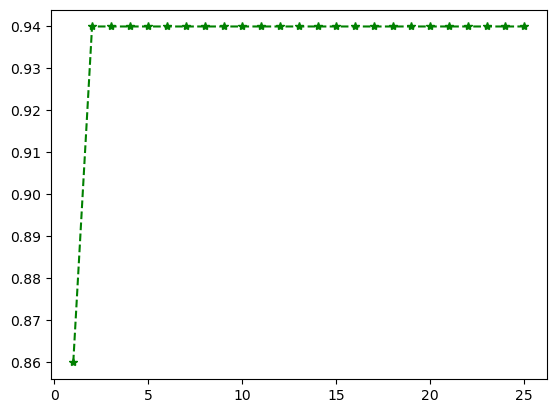

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
acc=[]
neigh=[]
for i in range(1,26):
    knn= KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred= knn.predict(x_test)
    accu= accuracy_score(y_test, y_pred)
    acc.append(accu)
    neigh.append(i)
n=acc.index(max(acc))+1
print(n)

plt.plot(neigh,acc,'*--g')
plt.show()

In [52]:
knn= KNeighborsClassifier(n_neighbors=n)
knn.fit(x_train,y_train)
knn.predict([[30,45000,5,3,10,1,0,0,1,0,1,0,0]])

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [53]:
df= pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [54]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [55]:
df=pd.get_dummies(data=df, drop_first=True)
df.columns

Index(['age', 'bmi', 'children', 'expenses', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [56]:
x=df[['age', 'bmi', 'children', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest']]
y=df['expenses']

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
T=[]
R=[]
MSE=[]
test=[0.1,0.2,0.3,0.4,0.5]
for i in test:
    for j in range(1,51):
        x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=i,random_state=j)
        lr=LinearRegression()
        lr.fit(x_train, y_train)
        y_pred=lr.predict(x_test)
        mse=mean_squared_error(y_test,y_pred)
        MSE.append(mse)
        R.append(j)
        T.append(i)
        

In [60]:
data={'test_size':T,'radom_state':R,'MSE':MSE}
df=pd.DataFrame(data)
df

,test_size,radom_state,MSE
0,0.1,1,4.309228e+07
1,0.1,2,3.389797e+07
2,0.1,3,3.951443e+07
3,0.1,4,3.988952e+07
4,0.1,5,3.123591e+07
...,...,...,...
245,0.5,46,3.709642e+07
246,0.5,47,3.420950e+07
247,0.5,48,3.501184e+07
248,0.5,49,3.625246e+07


In [61]:
df['MSE'].min()

25964185.138925117

In [63]:
df[df['MSE']==25964185.138925117]

,test_size,radom_state,MSE
35,0.1,36,2.596419e+07
